<a href="https://www.kaggle.com/code/sonawanelalitsunil/procurement-strategy-kraljic-matrix-ml-100?scriptVersionId=235638169" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/procurement-strategy-dataset-for-kraljic-matrix/realistic_kraljic_dataset.csv


## Title: Procurement Strategy - Kraljic Matrix

#### Description: A dataset that classifies procurement items based on Kraljic's Portfolio Matrix, categorizing them into four quadrants: strategic, leverage, bottleneck, and non-critical. It helps organizations develop tailored procurement strategies based on the importance and risk of each item.










## Import dataset

In [2]:
df = pd.read_csv('/kaggle/input/procurement-strategy-dataset-for-kraljic-matrix/realistic_kraljic_dataset.csv')

In [3]:
df.head()

,Product_ID,Product_Name,Supplier_Region,Lead_Time_Days,Order_Volume_Units,Cost_per_Unit,Supply_Risk_Score,Profit_Impact_Score,Environmental_Impact,Single_Source_Risk,Kraljic_Category
0,P001,Semiconductors,South America,81,171,255.03,5,5,4,Yes,Strategic
1,P002,Semiconductors,South America,8,763,380.33,5,4,4,Yes,Strategic
2,P003,Pharma APIs,Asia,65,413,385.24,4,5,5,Yes,Strategic
3,P004,Semiconductors,South America,70,882,287.64,5,5,5,Yes,Strategic
4,P005,Lithium Batteries,Asia,15,120,382.26,4,4,4,Yes,Strategic


In [4]:
df.tail()

,Product_ID,Product_Name,Supplier_Region,Lead_Time_Days,Order_Volume_Units,Cost_per_Unit,Supply_Risk_Score,Profit_Impact_Score,Environmental_Impact,Single_Source_Risk,Kraljic_Category
995,P996,Printer Ink,Global,19,19648,10.20,2,1,1,No,Non-Critical
996,P997,Cleaning Supplies,Global,21,19143,15.30,1,2,1,No,Non-Critical
997,P998,Uniforms,Global,70,5352,30.23,1,3,2,No,Non-Critical
998,P999,Printer Ink,Global,44,18070,30.73,1,1,2,No,Non-Critical
999,P1000,Cleaning Supplies,Global,76,9018,29.98,1,3,1,No,Non-Critical


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Product_ID            1000 non-null   object 
 1   Product_Name          1000 non-null   object 
 2   Supplier_Region       1000 non-null   object 
 3   Lead_Time_Days        1000 non-null   int64  
 4   Order_Volume_Units    1000 non-null   int64  
 5   Cost_per_Unit         1000 non-null   float64
 6   Supply_Risk_Score     1000 non-null   int64  
 7   Profit_Impact_Score   1000 non-null   int64  
 8   Environmental_Impact  1000 non-null   int64  
 9   Single_Source_Risk    1000 non-null   object 
 10  Kraljic_Category      1000 non-null   object 
dtypes: float64(1), int64(5), object(5)
memory usage: 86.1+ KB


In [6]:
df.describe()

,Lead_Time_Days,Order_Volume_Units,Cost_per_Unit,Supply_Risk_Score,Profit_Impact_Score,Environmental_Impact
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,47.508000,4753.182000,169.390440,2.988000,3.024000,2.778000
std,23.630454,5625.105273,132.104809,1.537602,1.542661,1.392356
min,7.000000,50.000000,10.090000,1.000000,1.000000,1.000000
25%,27.000000,363.000000,50.460000,1.000000,2.000000,2.000000
50%,48.000000,1105.500000,130.640000,3.000000,3.000000,2.500000
75%,67.000000,8111.750000,255.165000,4.250000,5.000000,4.000000
max,89.000000,19940.000000,499.320000,5.000000,5.000000,5.000000


In [7]:
df.isnull().sum()

Product_ID              0
Product_Name            0
Supplier_Region         0
Lead_Time_Days          0
Order_Volume_Units      0
Cost_per_Unit           0
Supply_Risk_Score       0
Profit_Impact_Score     0
Environmental_Impact    0
Single_Source_Risk      0
Kraljic_Category        0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.shape

(1000, 11)

In [10]:
df.dtypes

Product_ID               object
Product_Name             object
Supplier_Region          object
Lead_Time_Days            int64
Order_Volume_Units        int64
Cost_per_Unit           float64
Supply_Risk_Score         int64
Profit_Impact_Score       int64
Environmental_Impact      int64
Single_Source_Risk       object
Kraljic_Category         object
dtype: object

In [11]:
df.columns

Index(['Product_ID', 'Product_Name', 'Supplier_Region', 'Lead_Time_Days',
       'Order_Volume_Units', 'Cost_per_Unit', 'Supply_Risk_Score',
       'Profit_Impact_Score', 'Environmental_Impact', 'Single_Source_Risk',
       'Kraljic_Category'],
      dtype='object')

## Data visualizations

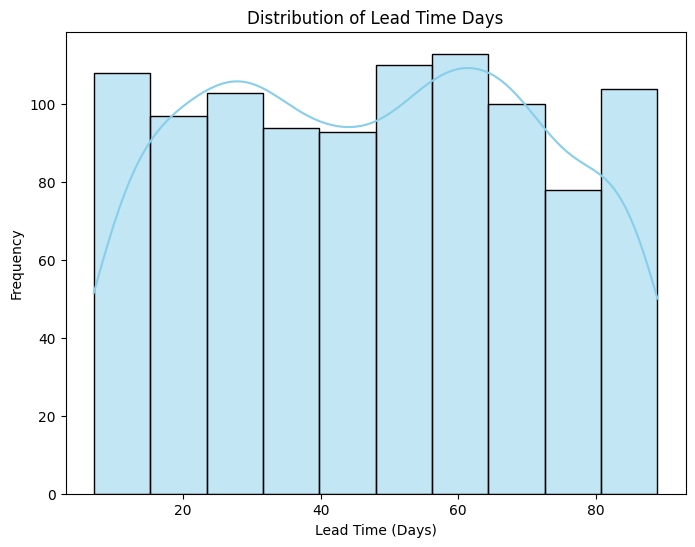

In [12]:
# 1. Distribution of Lead Time
plt.figure(figsize=(8, 6))
sns.histplot(df['Lead_Time_Days'], kde=True, bins=10, color='skyblue')
plt.title('Distribution of Lead Time Days')
plt.xlabel('Lead Time (Days)')
plt.ylabel('Frequency')
plt.show()

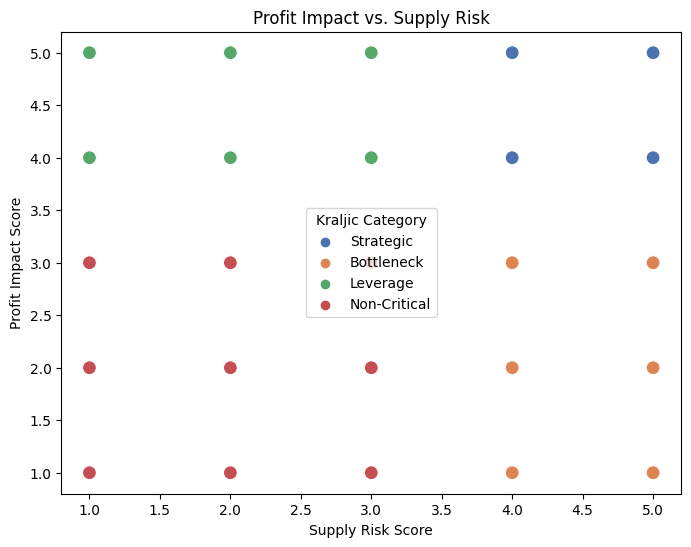

In [13]:
# 2. Profit Impact vs. Supply Risk (Scatter Plot)
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Supply_Risk_Score', y='Profit_Impact_Score', data=df, hue='Kraljic_Category', palette='deep', s=100)
plt.title('Profit Impact vs. Supply Risk')
plt.xlabel('Supply Risk Score')
plt.ylabel('Profit Impact Score')
plt.legend(title='Kraljic Category')
plt.show()

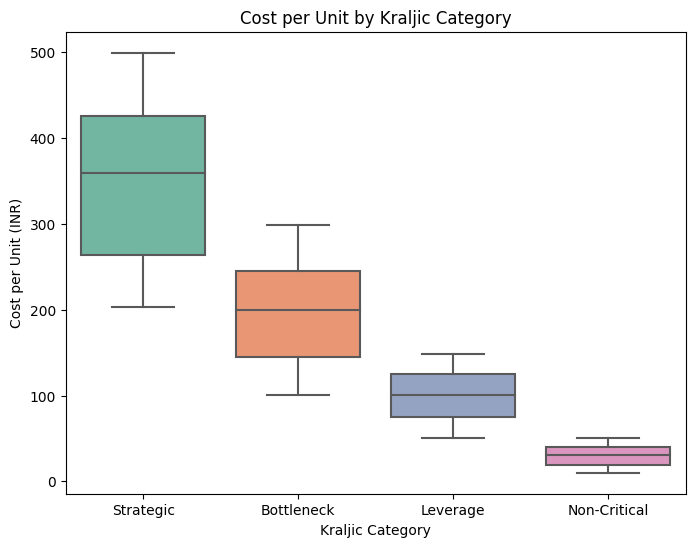

In [14]:
# 3. Boxplot of Cost per Unit by Kraljic Category
plt.figure(figsize=(8, 6))
sns.boxplot(x='Kraljic_Category', y='Cost_per_Unit', data=df, palette='Set2')
plt.title('Cost per Unit by Kraljic Category')
plt.xlabel('Kraljic Category')
plt.ylabel('Cost per Unit (INR)')
plt.show()


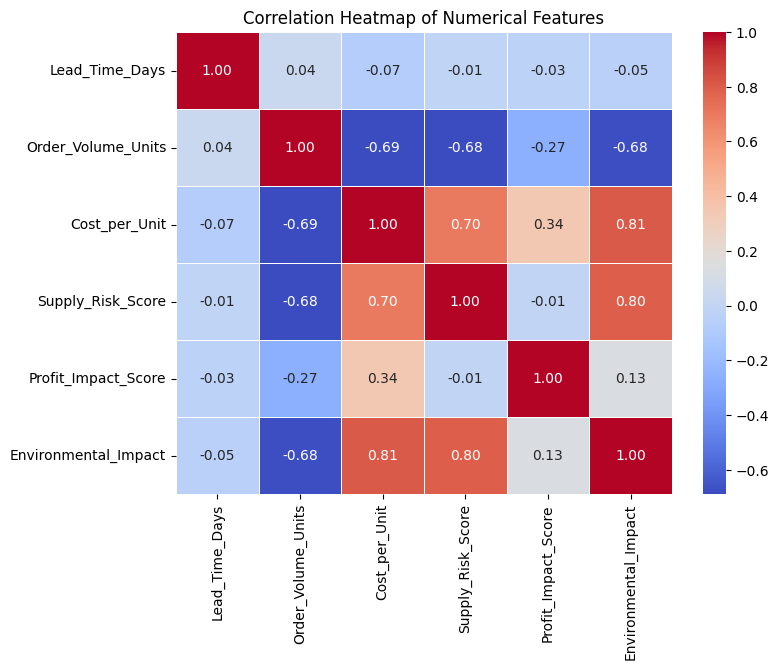

In [15]:
# Ensure only numeric columns are selected for the correlation matrix
numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns

# Calculate correlation matrix for only numeric columns
correlation_matrix = df[numeric_columns].corr()

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()


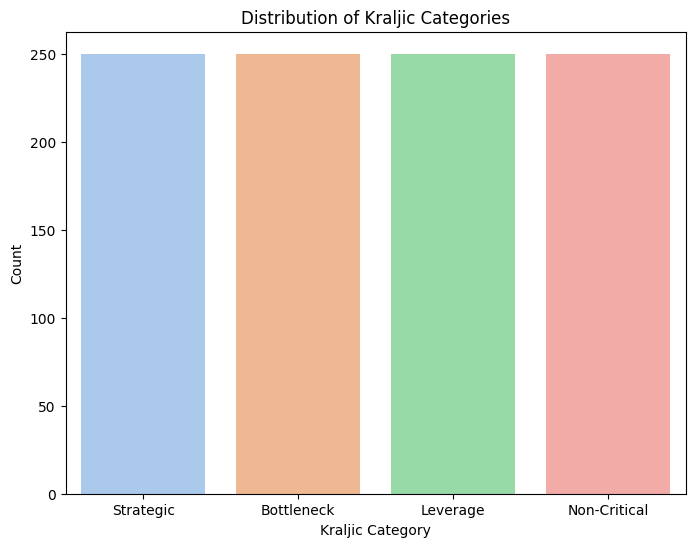

In [16]:
# 5. Kraljic Category Distribution
plt.figure(figsize=(8, 6))
sns.countplot(x='Kraljic_Category', data=df, palette='pastel')
plt.title('Distribution of Kraljic Categories')
plt.xlabel('Kraljic Category')
plt.ylabel('Count')
plt.show()


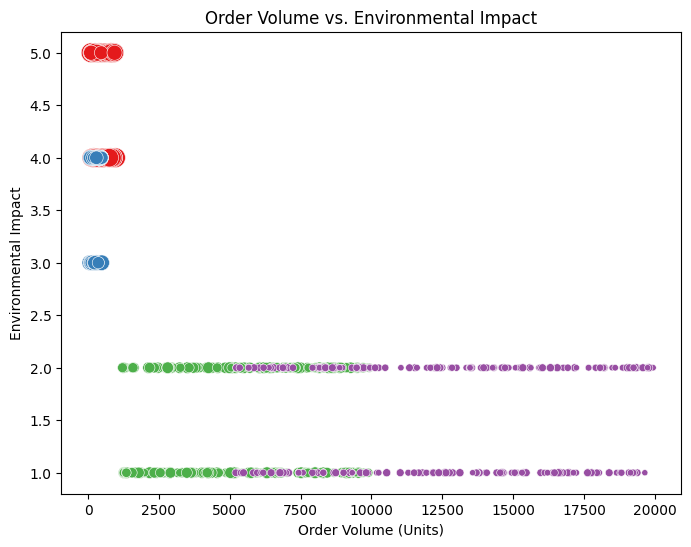

In [17]:
# 6. Order Volume vs. Environmental Impact (Bubble Plot)
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Order_Volume_Units', y='Environmental_Impact', size='Cost_per_Unit', sizes=(20, 200), 
                data=df, hue='Kraljic_Category', palette='Set1', legend=False)
plt.title('Order Volume vs. Environmental Impact')
plt.xlabel('Order Volume (Units)')
plt.ylabel('Environmental Impact')
plt.show()


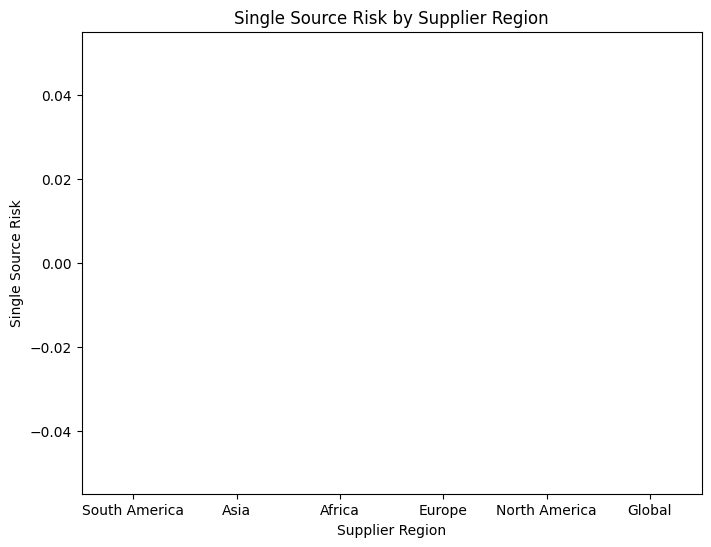

In [18]:
# Convert 'Single_Source_Risk' to numeric if it's categorical
df['Single_Source_Risk'] = pd.to_numeric(df['Single_Source_Risk'], errors='coerce')

# Replot the bar plot
plt.figure(figsize=(8, 6))
sns.barplot(x='Supplier_Region', y='Single_Source_Risk', data=df, palette='viridis')
plt.title('Single Source Risk by Supplier Region')
plt.xlabel('Supplier Region')
plt.ylabel('Single Source Risk')
plt.show()


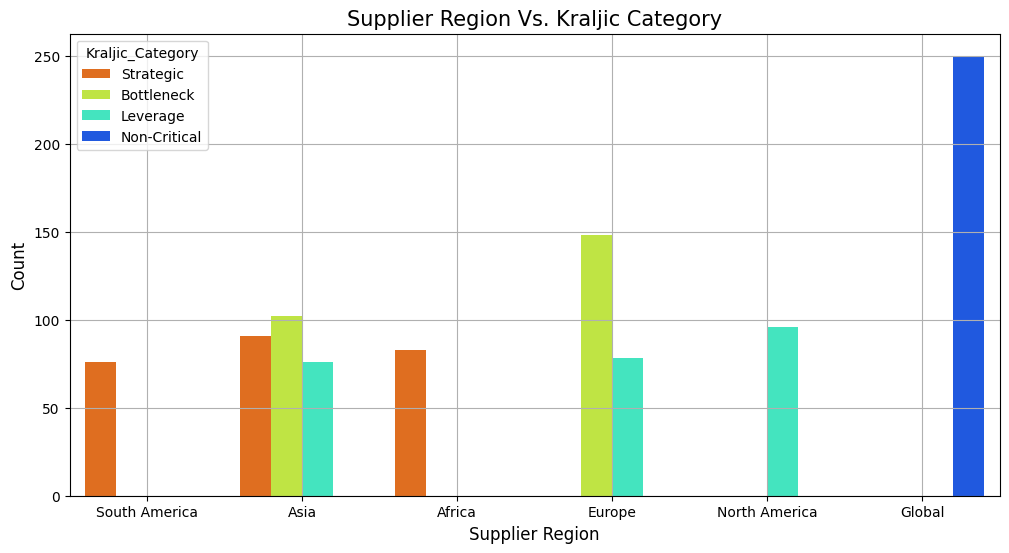

In [19]:
plt.figure(figsize=(12,6))
sns.countplot(x=df['Supplier_Region'], hue=df['Kraljic_Category'], palette='jet_r')
plt.title('Supplier Region Vs. Kraljic Category', fontsize=15)
plt.xlabel('Supplier Region', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.grid()
plt.show()

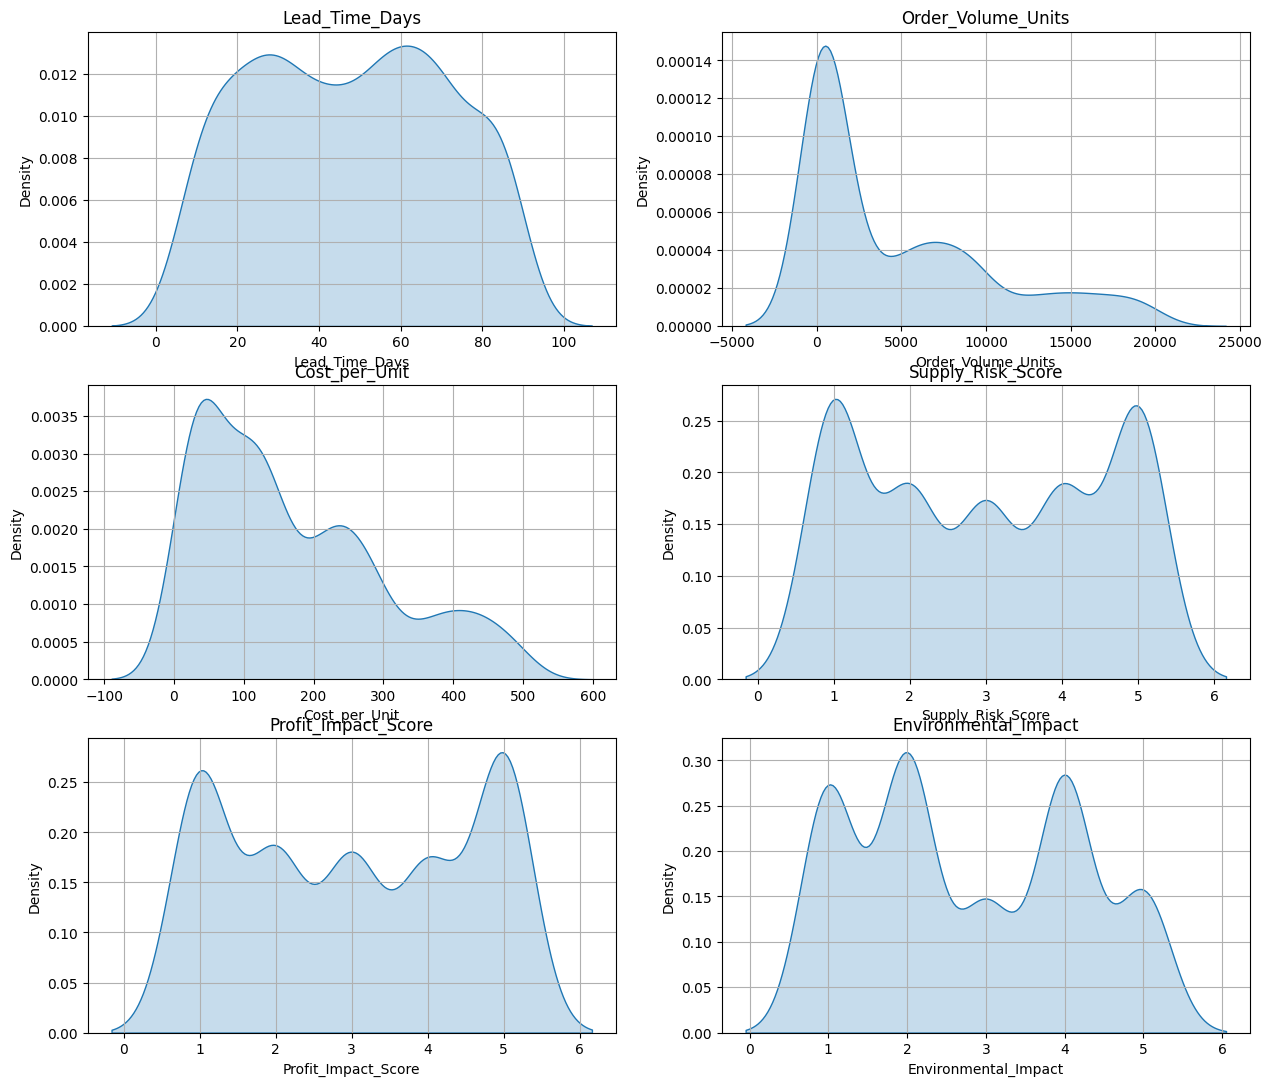

In [20]:
plt.figure(figsize=(15,13))
for idx, cols in enumerate(['Lead_Time_Days', 'Order_Volume_Units', 'Cost_per_Unit', 
                           'Supply_Risk_Score', 'Profit_Impact_Score', 'Environmental_Impact']):
    plt.subplot(3, 2, idx + 1)
    sns.kdeplot(x=cols, data=df, shade=True)
    plt.grid()
    plt.title(cols)
plt.show()

## Predictive modeling

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

In [22]:
df.drop('Product_ID',axis=1, inplace=True)

In [23]:
encoder = LabelEncoder()
for i in ['Product_Name', 'Supplier_Region', 'Single_Source_Risk','Kraljic_Category']:
    df[i] = encoder.fit_transform(df[i])

In [24]:
X = df.drop('Kraljic_Category', axis=1)
y = df['Kraljic_Category']

X_train,X_test, y_train,y_test = train_test_split(X,y , test_size=0.2)
print(f"X_train Shape: {X_train.shape}")
print(f"Y_train Shape: {y_train.shape}")
print(f"X_test Shape: {X_test.shape}")
print(f"y_test Shape: {y_test.shape}")

X_train Shape: (800, 9)
Y_train Shape: (800,)
X_test Shape: (200, 9)
y_test Shape: (200,)


Random Forest Confusion Matrix:
[[46  0  0  0]
 [ 0 56  0  0]
 [ 0  0 56  0]
 [ 0  0  0 42]]


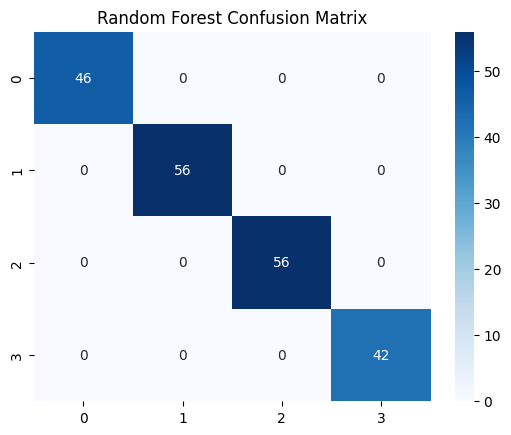

In [25]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Predict on test set
y_pred_rf = rf_model.predict(X_test)

# Confusion Matrix for Random Forest
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)
print("Random Forest Confusion Matrix:")
print(conf_matrix_rf)
sns.heatmap(conf_matrix_rf, annot=True, cmap='Blues', fmt='d')
plt.title('Random Forest Confusion Matrix')
plt.show()


Logistic Regression Confusion Matrix:
[[44  0  0  2]
 [ 0 53  2  1]
 [ 0  0 56  0]
 [ 3  0  0 39]]


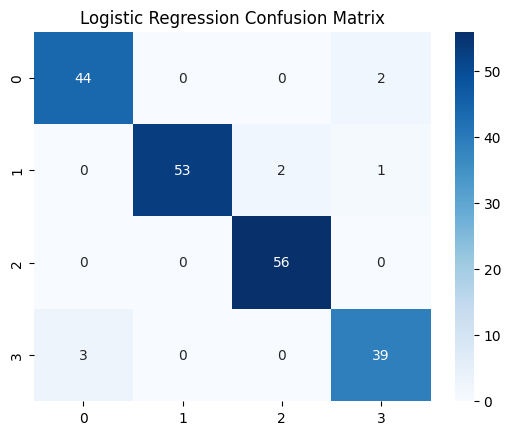

In [26]:
log_reg_model = LogisticRegression(random_state=42)
log_reg_model.fit(X_train, y_train)

# Predict on test set
y_pred_log_reg = log_reg_model.predict(X_test)

# Confusion Matrix for Logistic Regression
conf_matrix_log_reg = confusion_matrix(y_test, y_pred_log_reg)
print("Logistic Regression Confusion Matrix:")
print(conf_matrix_log_reg)
sns.heatmap(conf_matrix_log_reg, annot=True, cmap='Blues', fmt='d')
plt.title('Logistic Regression Confusion Matrix')
plt.show()


Support Vector Classifier Confusion Matrix:
[[46  0  0  0]
 [ 0 46  2  8]
 [ 0 21 35  0]
 [18  0  0 24]]


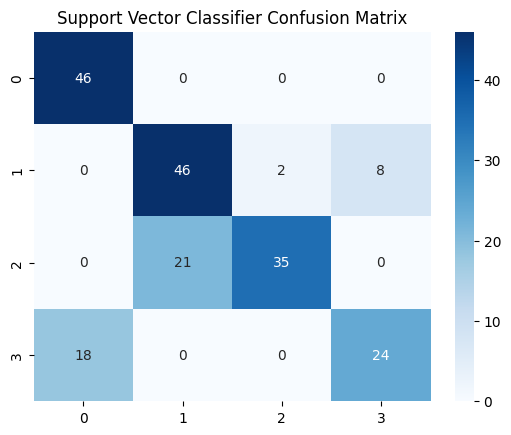

In [27]:
svc_model = SVC(random_state=42)
svc_model.fit(X_train, y_train)

# Predict on test set
y_pred_svc = svc_model.predict(X_test)

# Confusion Matrix for SVC
conf_matrix_svc = confusion_matrix(y_test, y_pred_svc)
print("Support Vector Classifier Confusion Matrix:")
print(conf_matrix_svc)
sns.heatmap(conf_matrix_svc, annot=True, cmap='Blues', fmt='d')
plt.title('Support Vector Classifier Confusion Matrix')
plt.show()


K-Nearest Neighbors Confusion Matrix:
[[44  0  0  2]
 [ 0 47  9  0]
 [ 0 10 46  0]
 [10  0  0 32]]


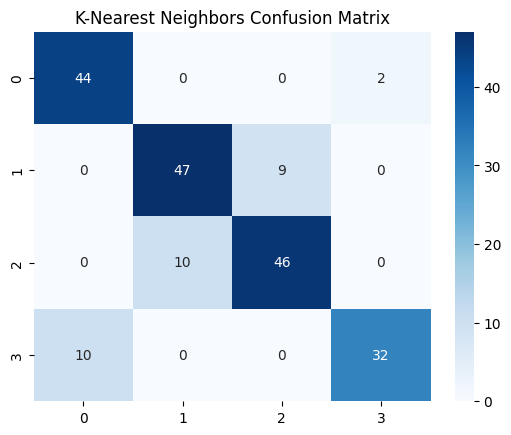

In [28]:
knn_model = KNeighborsClassifier()
knn_model.fit(X_train, y_train)

# Predict on test set
y_pred_knn = knn_model.predict(X_test)

# Confusion Matrix for KNN
conf_matrix_knn = confusion_matrix(y_test, y_pred_knn)
print("K-Nearest Neighbors Confusion Matrix:")
print(conf_matrix_knn)
sns.heatmap(conf_matrix_knn, annot=True, cmap='Blues', fmt='d')
plt.title('K-Nearest Neighbors Confusion Matrix')
plt.show()


Decision Tree Confusion Matrix:
[[45  0  0  1]
 [ 0 56  0  0]
 [ 0  0 56  0]
 [ 0  0  0 42]]


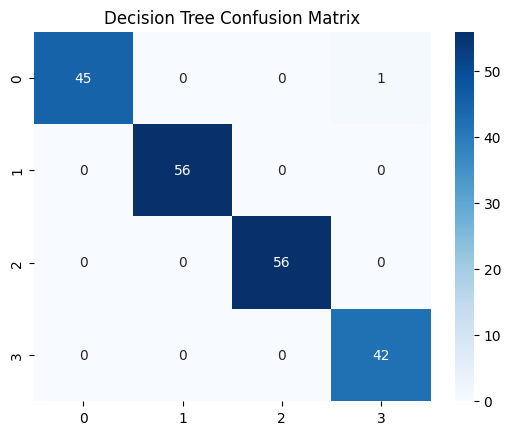

In [29]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Predict on test set
y_pred_dt = dt_model.predict(X_test)

# Confusion Matrix for Decision Tree
conf_matrix_dt = confusion_matrix(y_test, y_pred_dt)
print("Decision Tree Confusion Matrix:")
print(conf_matrix_dt)
sns.heatmap(conf_matrix_dt, annot=True, cmap='Blues', fmt='d')
plt.title('Decision Tree Confusion Matrix')
plt.show()


Decision Tree Confusion Matrix:
[[45  0  0  1]
 [ 0 56  0  0]
 [ 0  0 56  0]
 [ 0  0  0 42]]


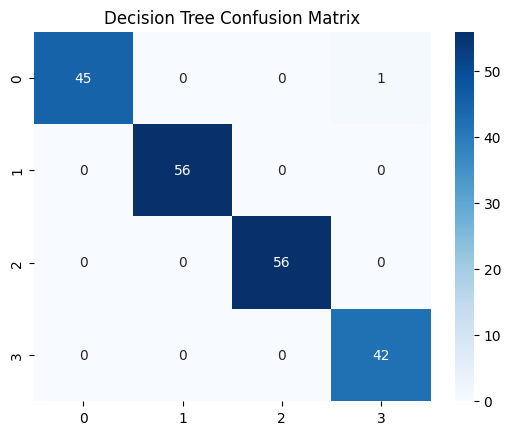

In [30]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Predict on test set
y_pred_dt = dt_model.predict(X_test)

# Confusion Matrix for Decision Tree
conf_matrix_dt = confusion_matrix(y_test, y_pred_dt)
print("Decision Tree Confusion Matrix:")
print(conf_matrix_dt)
sns.heatmap(conf_matrix_dt, annot=True, cmap='Blues', fmt='d')
plt.title('Decision Tree Confusion Matrix')
plt.show()


Naive Bayes Confusion Matrix:
[[46  0  0  0]
 [ 0 56  0  0]
 [ 0  0 56  0]
 [ 0  0  0 42]]


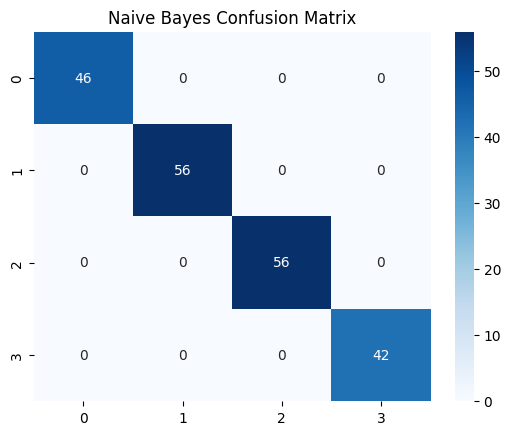

In [31]:
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

# Predict on test set
y_pred_nb = nb_model.predict(X_test)

# Confusion Matrix for Naive Bayes
conf_matrix_nb = confusion_matrix(y_test, y_pred_nb)
print("Naive Bayes Confusion Matrix:")
print(conf_matrix_nb)
sns.heatmap(conf_matrix_nb, annot=True, cmap='Blues', fmt='d')
plt.title('Naive Bayes Confusion Matrix')
plt.show()


In [32]:
# Print classification reports for each model
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_log_reg))

print("Support Vector Classifier Classification Report:")
print(classification_report(y_test, y_pred_svc))

print("K-Nearest Neighbors Classification Report:")
print(classification_report(y_test, y_pred_knn))

print("Decision Tree Classification Report:")
print(classification_report(y_test, y_pred_dt))

print("Naive Bayes Classification Report:")
print(classification_report(y_test, y_pred_nb))


Random Forest Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        46
           1       1.00      1.00      1.00        56
           2       1.00      1.00      1.00        56
           3       1.00      1.00      1.00        42

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95        46
           1       1.00      0.95      0.97        56
           2       0.97      1.00      0.98        56
           3       0.93      0.93      0.93        42

    accuracy                           0.96       200
   macro avg       0.96      0.96      0.96       200
weighted avg       0.96      0.96      0.96       200

Support Vector Classifier Classification Report:
 

## Thank you..pls upvote!!!